# 1 跨域
### 跨域资源共享
跨域资源共享（CORS）是一种浏览器安全机制，用于允许运行在一个源（Origin）的 Web 应用，通过浏览器向另一个源的服务器发起跨域 HTTP 请求，并在服务器授权的前提下获取资源。

同源的三个条件：协议、域名、端口

前端-------------------------------后端-------------------------是否跨域

http://localhost:5173-------http://localhost:8000--------------跨域


http://example.com---------http://api.example.com--------------跨域


http://example.co-----------http://example.com-----------------×不跨域

前端Vue：http://localhost:5173/      后端 FastAPI: http://127.0.0.1:8000/

只有协议相同，域名端口都不同，即出现了跨域问题。所以被浏览器安全机制拦截（查看新闻分类是否在前端显示的时候）

### CORS中间件
CORS：让后端主动告诉浏览器这个前端“允许访问“

In [ ]:
from fastapi.middleware.cors import CORSMiddleware
# 允许的来源（可以是域名列表）
origins = [
    "http://localhost",
    "http://localhost:3000",
    "https://your-frontend-domain.com"
]
# 添加 CORS 中间件
app.add_middleware(
        CORSMiddleware, 
        allow_origins=["*"],  # 允许访问的源
        allow_credentials=True， # 允许携带 Cookie
        allow_methods=["*"],  # 允许所有请求方法
        allow_headers=["*"],  # 允许所有请求头
)

# 2 新闻列表
### 获取新闻列表

Python：官方推荐下划线（create_at）
JavaScript/TypeScript：强制小驼峰（createAt）
数据库：create_at（下划线，MySQL 标准）

In [ ]:
@router.get ("/list")
async def get_news (
    category_id: int = Query(..., alias="categoryId"), # alias设置别名，前端传categoryId，后端接收category_id
    page: int = 1,
    page_size: int = Query(10, le=100, alias="pageSize")
):
return {
    "code": 200,
    "message": "success",
    "data": {
    "list: "news_list",
    "total": "total_count",
    "hasMore": "has_more"
    }
}

### 获取新闻列表-查询功能
查询功能响应结果：当前分类新闻列表、新闻总量、是否还有更多新闻
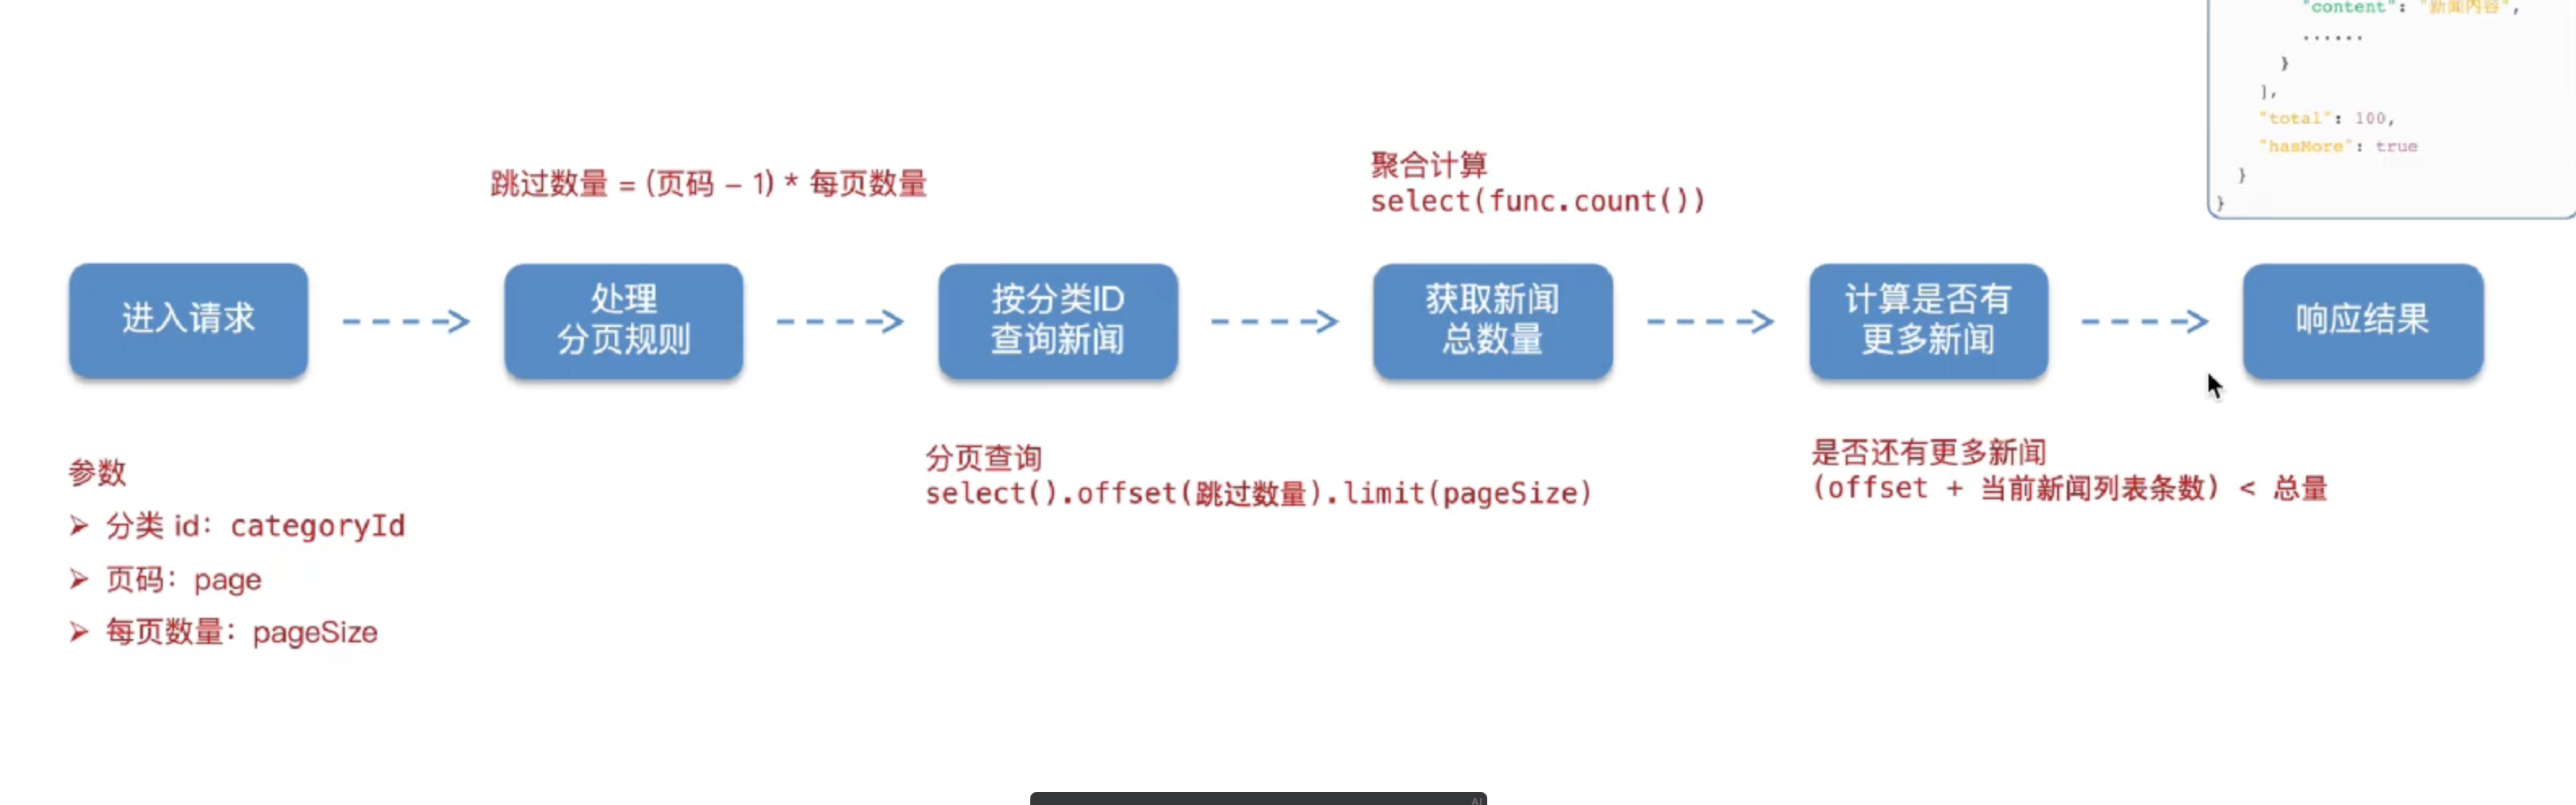

# 3 新闻详情
### 获取新闻详情


In [ ]:
@router.get("/detail")
async def read_news_detail(news_id: int=Query(..., alias="id")) :
    return {
        "code": 200,
        "message": "success",
        "data": {
            "id": "新闻id",
            "title": "新闻标题",
            "content": "",
            ...
            "relatedNews": "相关新闻"
        }
    }

响应结果：当前新闻详情 + 增加 1 次浏览量 + 相关新闻（同分类id的新闻）
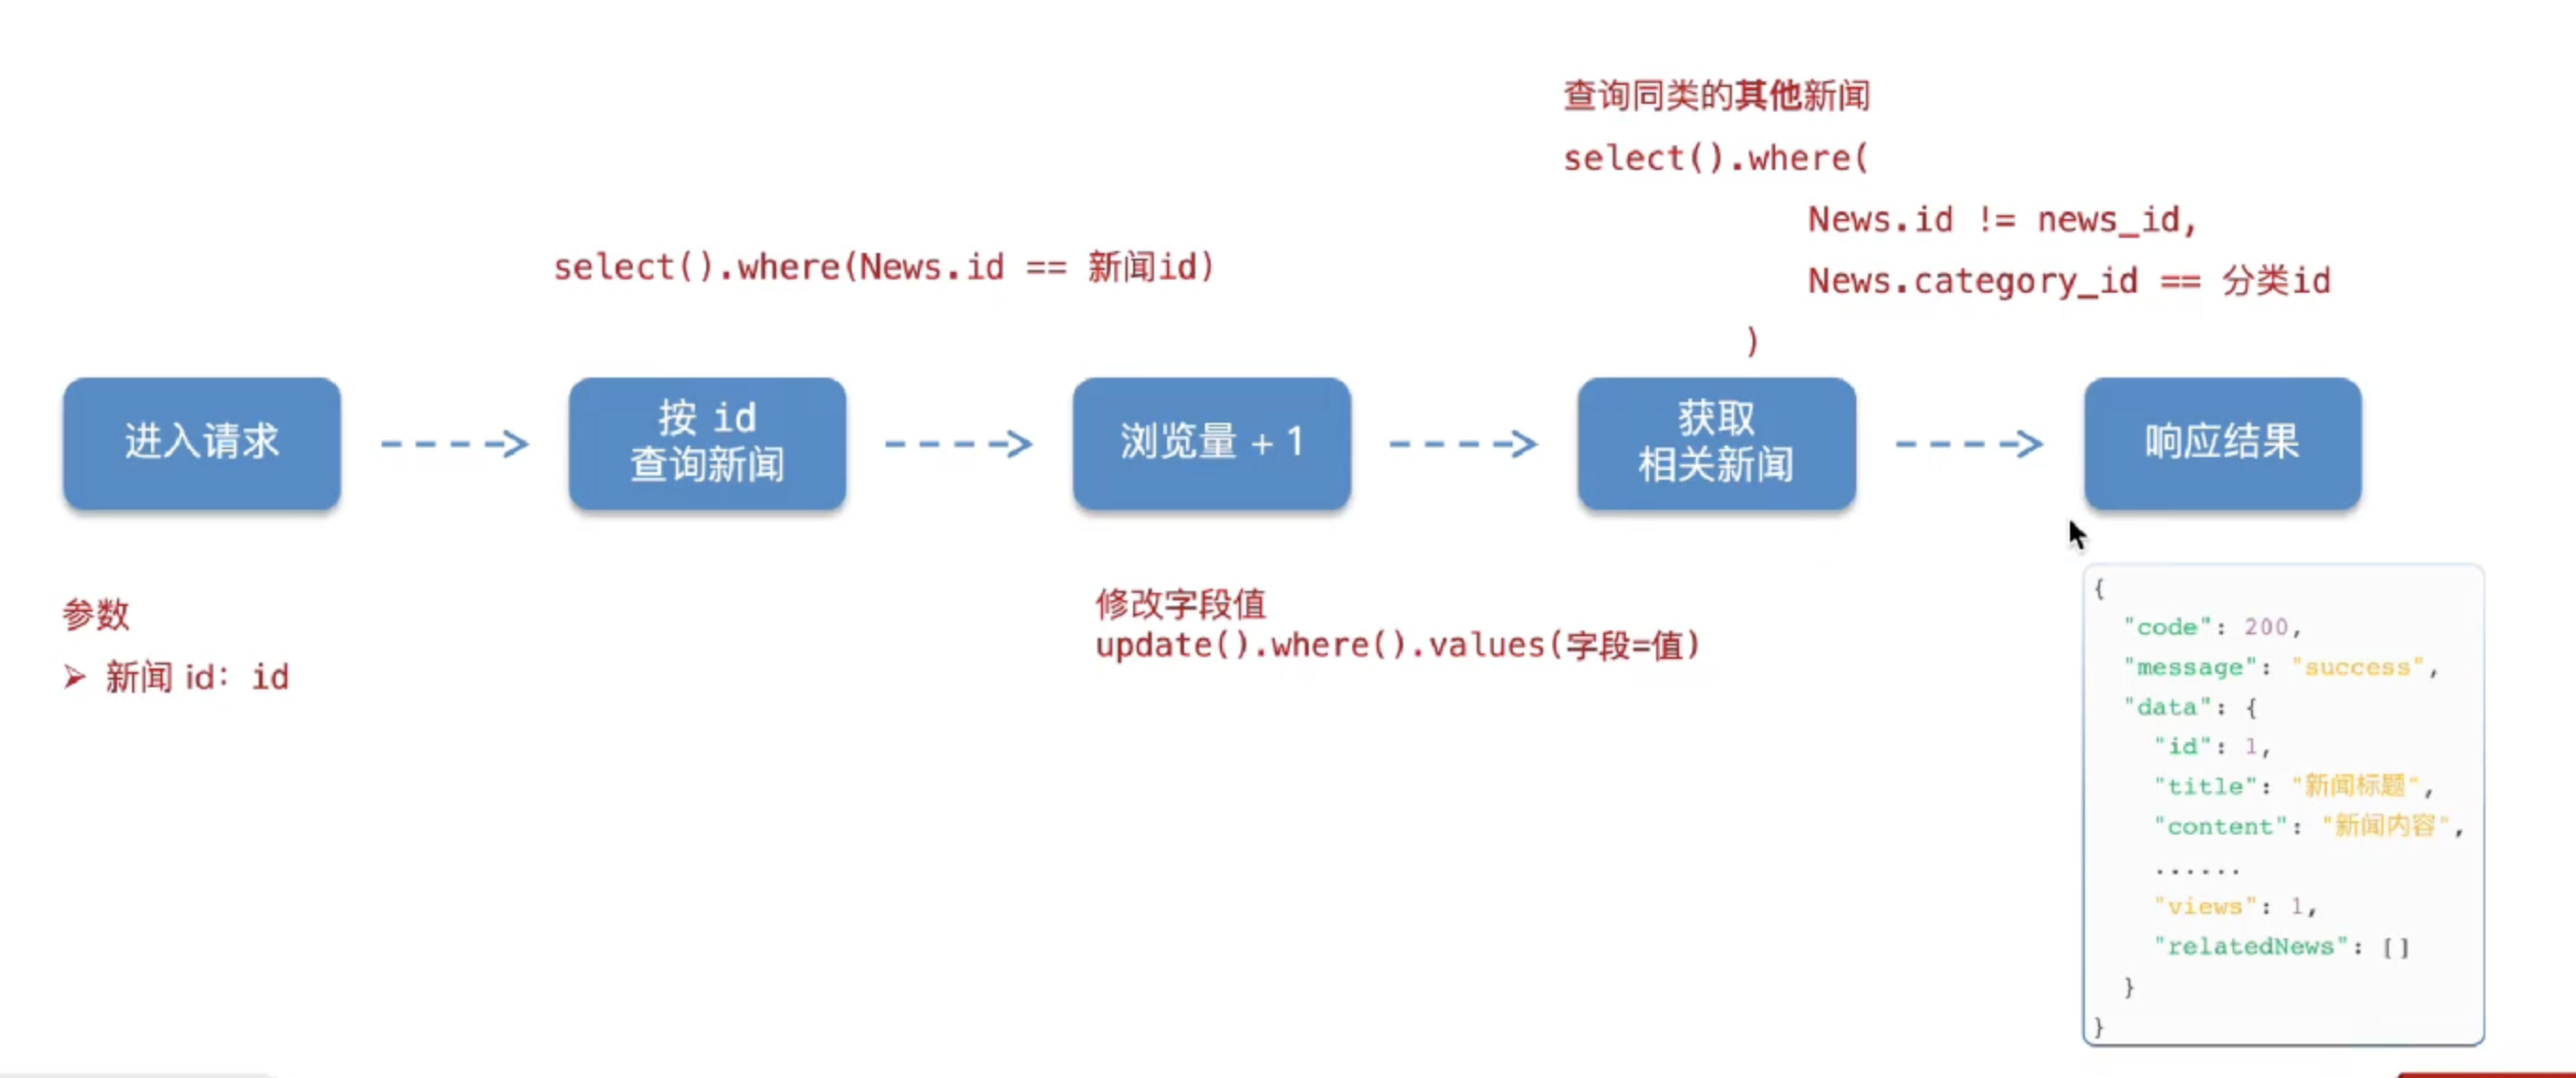